<a href="https://colab.research.google.com/github/ankitkumargupta001/jupyter-notebooks/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Why n-1 in variance for population.

> So, the idea behind is go generate a list of random variables of size `N` and calculate its population mean and variance.
Then, we pick random samples from the list with sample size `n` in `[2,10]`, and calcuate sample mean and variance and compare.


## Comparison
1. Sample Mean vs Sample Variance
2. Sample Variance / Population Variance % vs Sample Size n

## Population

In [11]:
import numpy as np
import random

rng = np.random.default_rng()

population = rng.integers(low=1, high=1000, size=2000)
print(f"Population: {population[:10]}")

population_mean = np.mean(population)
print(f"Population Mean: {population_mean}")

population_variance = np.var(population)
print(f"Population Variance: {population_variance}")

Population: [717 831 860 232 409 879  53 190 331 358]
Population Mean: 494.5805
Population Variance: 85907.90051975


## Sample Calculations



In [12]:
samples = []
sample_sizes = rng.integers(low=2, high=11, size=4000)

for n in sample_sizes:
  # print(f"Sample Size: {n}")

  sample = rng.choice(population, size=n)
  # print(f"Sample {sample[:10]}")

  sample_mean = np.mean(sample)
  # print(f"Sample Mean: {sample_mean}")

  sample_variance = np.var(sample)
  # print(f"Sample Variance: {sample_variance}")

  samples.append({"n": n, "mean": sample_mean, "var": sample_variance})


Plotting

Sample Means: [264.75       595.3        489.88888889 521.75       465.77777778]
Sample Sizes: [ 4 10  9  8  9]
Sample Variances: [ 38153.1875      71388.01       100153.87654321  35115.4375
  54912.61728395]
Percentages: [np.float64(74.47690064524159), np.float64(90.42314129992758), np.float64(88.17254466618309), np.float64(87.51342977824095), np.float64(88.17254466618309)]


/tmp/ipykernel_7561/1916297480.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


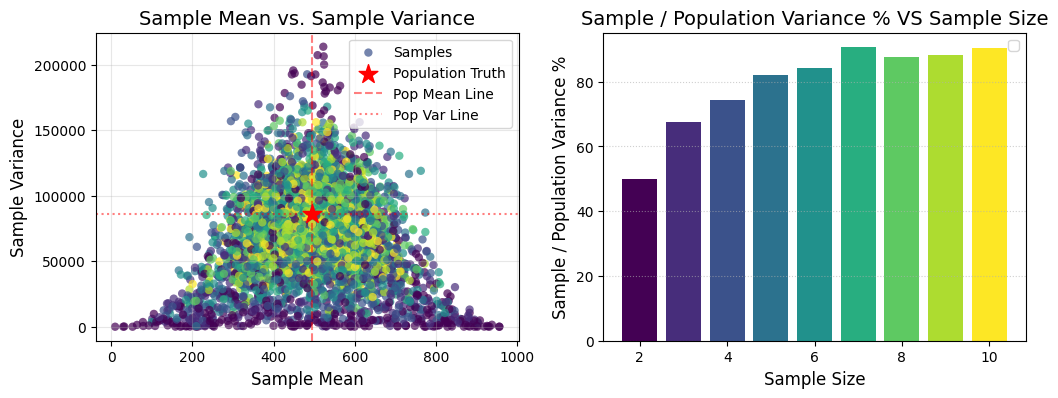

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

sample_means = np.array([sample["mean"] for sample in samples])
sample_variances = np.array([sample["var"] for sample in samples])
sample_sizes_arr = np.array([sample["n"] for sample in samples])

percentages = []
for n in sample_sizes_arr:
  avg_var_per_n = np.mean([sample["var"] for sample in samples if sample["n"] == n])
  percentages.append((avg_var_per_n / population_variance) * 100)

print(f"Sample Means: {sample_means[:5]}")
print(f"Sample Sizes: {sample_sizes_arr[:5]}")
print(f"Sample Variances: {sample_variances[:5]}")
print(f"Percentages: {percentages[:5]}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# PLOT 1 - SAMPLE MEAN VS SAMPLE VARIANCE
# plt.scatter(sample_means, sample_variances, color='blue', alpha=0.6, label='Samples')
ax1.scatter(sample_means, sample_variances, c=sample_sizes_arr, cmap='viridis', alpha=0.7, edgecolors='none', label='Samples')
ax1.scatter(population_mean, population_variance, color='red', marker='*', s=200, label='Population Truth')

ax1.axvline(x=population_mean, color='red', linestyle='--', alpha=0.5, label='Pop Mean Line')
ax1.axhline(y=population_variance, color='red', linestyle=':', alpha=0.5, label='Pop Var Line')

ax1.set_title('Sample Mean vs. Sample Variance', fontsize=14)
ax1.set_xlabel('Sample Mean', fontsize=12)
ax1.set_ylabel('Sample Variance', fontsize=12)
ax1.grid(True, linestyle='-', alpha=0.3)
ax1.legend()

# PLOT 2 - (SAMPLE VAR / POP VAR) % VS SAMPLE SIZE (n)
norm = plt.Normalize(sample_sizes_arr.min(), sample_sizes_arr.max())
colors = cm.viridis(norm(sample_sizes_arr))

ax2.bar(sample_sizes_arr, percentages, color=colors, alpha=0.7)
ax2.set_title('Sample / Population Variance % VS Sample Size', fontsize=14)
ax2.set_ylabel('Sample / Population Variance %', fontsize=12)
ax2.set_xlabel('Sample Size', fontsize=12)
# ax2.xticks(rotation=90, fontsize=8)
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.legend()

# Display the plot
plt.show()